In [1]:
import pandas as pd
import numpy as np
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, cohen_kappa_score, confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
class HybridDataset(Dataset):
    def __init__(self, X_seq, X_static, y, seq_lengths):
        self.X_seq = torch.FloatTensor(X_seq)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.LongTensor(y)
        self.seq_lengths = torch.LongTensor(seq_lengths)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_seq[idx],
            self.X_static[idx],
            self.seq_lengths[idx],
            self.y[idx]
        )


In [3]:
class HybridMaskedRecurrentModel(nn.Module):
    def __init__(self, seq_input_dim, static_dim, hidden_dim, num_classes, rnn_type="lstm"):
        super().__init__()
        self.rnn_type = rnn_type
        bidirectional = rnn_type == "bilstm"

        if rnn_type == "rnn":
            self.recurrent = nn.RNN(seq_input_dim, hidden_dim, batch_first=True)
        elif rnn_type == "lstm":
            self.recurrent = nn.LSTM(seq_input_dim, hidden_dim, batch_first=True)
        elif rnn_type == "gru":
            self.recurrent = nn.GRU(seq_input_dim, hidden_dim, batch_first=True)
        elif rnn_type == "bilstm":
            self.recurrent = nn.LSTM(
                seq_input_dim,
                hidden_dim,
                batch_first=True,
                bidirectional=True
            )

        out_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(out_dim + static_dim, num_classes)

    def forward(self, x_seq, x_static, seq_lengths):
        # pack sequence (IMPORTANT)
        packed = pack_padded_sequence(
            x_seq,
            seq_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
    
        packed_out, hidden = self.recurrent(packed)
    
        if self.rnn_type == "bilstm":
            h_n, _ = hidden
            out = torch.cat([h_n[-2], h_n[-1]], dim=1)
        elif self.rnn_type == "lstm":
            h_n, _ = hidden
            out = h_n[-1]
        else:
            out = hidden[-1]
    
        out = torch.cat([out, x_static], dim=1)
        return self.fc(out)


In [4]:
# Metrics
def gmean_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    per_class = []
    for i in range(cm.shape[0]):
        tp = cm[i,i]
        fn = cm[i].sum() - tp
        fp = cm[:,i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        per_class.append(np.sqrt(sens * spec))
    return np.prod(per_class) ** (1/len(per_class)) if per_class else 0

def gmean_per_class(y_true, y_pred, target_class):
    cm = confusion_matrix(y_true, y_pred)
    i = target_class
    tp = cm[i,i]
    fn = cm[i].sum() - tp
    fp = cm[:,i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return np.sqrt(recall * specificity)

def print_results(
    version_name,
    phase,
    y_true,
    y_pred,
    time_build_model=None,
    time_predict=None
):
    target_names = ['Excellent', 'Good', 'Average']

    print(f"\n{'='*30} {version_name} - Phase {phase} {'='*30}")
    print(classification_report(
        y_true,
        y_pred,
        digits=10,
        target_names=target_names
    ))

    # Precision / Recall / F1 theo từng class
    prec_per_class = precision_score(y_true, y_pred, average=None)
    rec_per_class  = recall_score(y_true, y_pred, average=None)
    f1_per_class   = f1_score(y_true, y_pred, average=None)

    # G-Mean per class
    gmean_classes = [
        gmean_per_class(y_true, y_pred, i)
        for i in range(len(target_names))
    ]

    print("G-Mean per class (one-vs-rest):")
    for idx, name in enumerate(target_names):
        print(f"  {name:<10}: {gmean_classes[idx]:.10f}")
        
    print()

    # ===== TẠO DICTIONARY METRICS =====
    metrics = {
        'Version': version_name,
        'Phase': phase,

        'TimeBuildModel': time_build_model,
        'TimePredict': time_predict,

        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAcc': balanced_accuracy_score(y_true, y_pred),

        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Precision Weighted': precision_score(y_true, y_pred, average='weighted'),

        'Recall Macro': recall_score(y_true, y_pred, average='macro'),
        'Recall Weighted': recall_score(y_true, y_pred, average='weighted'),

        'F1-Score Macro': f1_score(y_true, y_pred, average='macro'),
        'F1-Score Weighted': f1_score(y_true, y_pred, average='weighted'),

        'GMean': gmean_score(y_true, y_pred),

        'MCC': matthews_corrcoef(y_true, y_pred),
        'Kappa': cohen_kappa_score(y_true, y_pred),
    }

    # ===== THÊM METRIC CHO TỪNG CLASS =====
    for i, name in enumerate(target_names):
        metrics[f'Precision_{name}'] = prec_per_class[i]
        metrics[f'Recall_{name}'] = rec_per_class[i]
        metrics[f'F1-Score_{name}'] = f1_per_class[i]
        metrics[f'G-Mean_{name}'] = gmean_classes[i]

    # In ra console
    for k, v in metrics.items():
        if k not in ['Version', 'Phase'] and v is not None:
            print(f"{k:22} : {v:.10f}")

    return metrics

In [5]:
def evaluate_hybrid_model(
    model,
    loader,
    device,
    dataset_name,
    output_dir="results"
):
    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for xb_seq, xb_static, xb_len, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)
            xb_len = xb_len.to(device)

            outputs = model(xb_seq, xb_static, xb_len)
            probs = torch.softmax(outputs, dim=1)

            # FIX 1: preds lấy từ probs (KHÔNG từ outputs)
            preds = torch.argmax(probs, dim=1)

            # FIX 2: dùng append thay vì extend
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.numpy())

    # FIX 3: concat thay vì np.array
    y_true = np.concatenate(all_labels, axis=0)
    y_pred = np.concatenate(all_preds, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)

    # ===== Confusion Matrix =====
    cm = confusion_matrix(y_true, y_pred)

    cm_path = f"{output_dir}/confusion_matrix_{dataset_name}.csv"
    pd.DataFrame(cm).to_csv(cm_path, index=False)

    # Plot CM
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


    # ===== Probability matrix =====
    prob_path = f"{output_dir}/probability_matrix_{dataset_name}.csv"

    df_prob = pd.DataFrame(
        y_prob,
        columns=[f"Prob_Class_{i}" for i in range(y_prob.shape[1])]
    )
    df_prob["y_true"] = y_true
    df_prob["y_pred"] = y_pred

    df_prob.to_csv(prob_path, index=False)

    print(f"Saved confusion matrix to: {cm_path}")
    print(f"Saved probability matrix to: {prob_path}")

    return y_true, y_pred

In [6]:
def prepare_and_train_hybrid(train_path, val_path=None, rnn_type="lstm"):
    print(f"Loading train: {train_path}")
    df_train = pd.read_csv(train_path)

    if val_path:
        df_val = pd.read_csv(val_path)
        df = pd.concat([df_train, df_val], ignore_index=True)
        print(f"Combined train + val: {len(df)} samples")
    else:
        df = df_train
        print(f"Only train: {len(df)} samples")

    df = df.drop(columns=['user_id', 'course_id'], errors='ignore')

    # ===== Tách label =====
    y = df['label_3'].values
    df_features = df.drop('label_3', axis=1)

    # Lấy tất cả feature time-series của cả 4 phase
    phase_cols = [
        col for col in df_features.columns
        if any(f"_p{p}_" in col for p in ['1', '2', '3', '4'])
    ]
    
    phases_data = []
    
    for p in ['1', '2', '3', '4']:
        cols_p = [c for c in phase_cols if f"_p{p}_" in c]
        print(f"Phase {p}: {len(cols_p)} features")
        phases_data.append(df_features[cols_p].values)
    
    X_seq = np.stack(phases_data, axis=1)

    # ===== Timestep mask cho RNN =====
    seq_lengths = (np.abs(X_seq).sum(axis=2) > 0).sum(axis=1)

    print(f"Time-series shape: {X_seq.shape}")


    # ====== Tách feature static ======
    static_cols = [c for c in df_features.columns if c not in phase_cols]
    X_static = df_features[static_cols].values

    print(f"Static feature shape: {X_static.shape}")

    # ====== Chuẩn hóa ======
    scaler_seq = StandardScaler()
    N, T, F = X_seq.shape

    X_seq = scaler_seq.fit_transform(X_seq.reshape(-1, F)).reshape(N, T, F)
    X_seq = np.nan_to_num(
        X_seq,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )
    scaler_static = StandardScaler()
    X_static = scaler_static.fit_transform(X_static)
    X_static = np.nan_to_num(X_static, nan=0.0, posinf=0.0, neginf=0.0)

    # ===== Encode label =====
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    seq_lengths = np.maximum(seq_lengths, 1)

    print(f"Classes: {le.classes_}")

    # ===== Dataset =====
    dataset = HybridDataset(
        X_seq,
        X_static,
        y_enc,
        seq_lengths
    )
    loader = DataLoader(dataset, batch_size=256, shuffle=True)

    # ===== Model =====
    model = HybridMaskedRecurrentModel(
        seq_input_dim=F,
        static_dim=X_static.shape[1],
        hidden_dim=128,
        num_classes=len(le.classes_),
        rnn_type=rnn_type
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ===== Train =====
    model.train()
    best_loss = float('inf')
    patience = 10
    wait = 0

    for epoch in range(50):
        epoch_loss = 0

        for xb_seq, xb_static, xb_len, yb in loader:
            xb_seq = xb_seq.to(device)
            xb_static = xb_static.to(device)
            xb_len = xb_len.to(device)
            yb = yb.to(device)
        
            optimizer.zero_grad()
            out = model(xb_seq, xb_static, xb_len)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()


            epoch_loss += loss.item()

        epoch_loss /= len(loader)
        print(f"Epoch {epoch+1}: loss = {epoch_loss:.4f}")

        if epoch_loss < best_loss - 1e-4:
            best_loss = epoch_loss
            best_state = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    print("Training done")

    return model, scaler_seq, scaler_static, le, phase_cols, static_cols

In [7]:
def run_and_report_hybrid(
    model,
    loader,
    device,
    dataset_name,
    version_name="HybridModel",
    phase="All"
):
    y_true, y_pred = evaluate_hybrid_model(
        model, loader, device, dataset_name
    )

    metrics = print_results(
        version_name=version_name,
        phase=phase,
        y_true=y_true,
        y_pred=y_pred
    )

    metrics_path = f"results/metrics_{dataset_name}.csv"
    pd.DataFrame([metrics]).to_csv(metrics_path, index=False)

    print(f"Saved metrics to: {metrics_path}")

    return metrics

In [8]:
base_path = "/kaggle/input/lo-dataset/Raw/Raw"

In [9]:
import time

def run_experiment_hybrid(
    base_path,
    train_file,
    val_file,
    test_prefix,
    version_name,
    rnn_type="lstm"
):
    print(f"\n{'#'*5}")
    print(f"Version: {version_name}")
    print(f"{'#'*5}")

    train_path = f"{base_path}/{train_file}"
    val_path   = f"{base_path}/{val_file}"

    test_files = [
        f"{base_path}/{test_prefix}_1.csv",
        f"{base_path}/{test_prefix}_2.csv",
        f"{base_path}/{test_prefix}_3.csv",
        f"{base_path}/{test_prefix}_4.csv",
    ]

    # ===== Train =====
    start_train = time.perf_counter()

    model, scaler_seq, scaler_static, le, phase_cols, static_cols = \
        prepare_and_train_hybrid(
            train_path,
            val_path,
            rnn_type=rnn_type
        )

    time_build_model = time.perf_counter() - start_train
    results = []

    model.eval()
    with torch.no_grad():
        for phase, test_path in enumerate(test_files, 1):
            print(f"\n--- Test Phase {phase}: {test_path} ---")

            df_test = pd.read_csv(test_path)
            df_test = df_test.drop(columns=['user_id', 'course_id'], errors='ignore')

            # ===== Label =====
            y_test = df_test['label_3'].values
            y_test_enc = le.transform(y_test)

            df_features = df_test.drop('label_3', axis=1)

            # ===== Time-series =====
            phases_data = []
            for p in ['1', '2', '3', '4']:
                cols_p = [c for c in phase_cols if f"_p{p}_" in c]
                phases_data.append(df_features[cols_p].values)

            X_seq = np.stack(phases_data, axis=1)   # (N, T, F)

            # ===== Static =====
            X_static = df_features[static_cols].values

            phase_exist = (~np.isnan(X_seq)).any(axis=2)   # (N, T)

            seq_lengths = phase_exist.sum(axis=1)

            # KHÔNG drop sample
            seq_lengths = np.maximum(seq_lengths, 1)

            # Thay NaN bằng 0 để đưa vào model
            X_seq = np.nan_to_num(X_seq, nan=0.0)
            X_static = np.nan_to_num(X_static, nan=0.0)

            # ===== Scaling =====
            N, T, F = X_seq.shape
            X_seq_scaled = scaler_seq.transform(
                X_seq.reshape(-1, F)
            ).reshape(N, T, F)

            X_static_scaled = scaler_static.transform(X_static)

            # ===== Tensor =====
            X_seq_tensor = torch.FloatTensor(X_seq_scaled).to(device)
            X_static_tensor = torch.FloatTensor(X_static_scaled).to(device)
            seq_lengths_tensor = torch.LongTensor(seq_lengths).to(device)

            # ===== Predict =====
            start_pred = time.perf_counter()

            outputs = model(
                X_seq_tensor,
                X_static_tensor,
                seq_lengths_tensor
            )

            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            time_predict = time.perf_counter() - start_pred

            # ===== Metrics =====
            res = print_results(
                version_name=version_name,
                phase=phase,
                y_true=y_test_enc,
                y_pred=preds,
                time_build_model=time_build_model,
                time_predict=time_predict
            )

            # ===== Confusion + Probability =====
            run_and_report_hybrid(
                model=model,
                loader=DataLoader(
                    HybridDataset(
                        X_seq_scaled,
                        X_static_scaled,
                        y_test_enc,
                        seq_lengths
                    ),
                    batch_size=256,
                    shuffle=False
                ),
                device=device,
                dataset_name=f"{version_name}_phase{phase}"
            )

            results.append(res)

    # ===== Summary dataframe =====
    df = pd.DataFrame(results).round(10)

    # Đổi tên cột cho đúng
    df = df.rename(columns={
        "PrecMacro": "Precision Macro",
        "PrecWeighted": "Precision Weighted",
        "RecMacro": "Recall Macro",
        "RecWeighted": "Recall Weighted",
        "F1Macro": "F1-Score Macro",
        "F1Weighted": "F1-Score Weighted",
    })

    ordered_cols = [
        "Version",
        "Phase",
        "TimeBuildModel",
        "TimePredict",
        "Accuracy",
        "BalancedAcc",
        "Precision Macro",
        "Precision Weighted",
        "Recall Macro",
        "Recall Weighted",
        "F1-Score Macro",
        "F1-Score Weighted",
        "GMean",
        "MCC",
        "Kappa",

        "Precision_Excellent",
        "Recall_Excellent",
        "F1-Score_Excellent",
        "G-Mean_Excellent",

        "Precision_Good",
        "Recall_Good",
        "F1-Score_Good",
        "G-Mean_Good",

        "Precision_Average",
        "Recall_Average",
        "F1-Score_Average",
        "G-Mean_Average",
    ]

    ordered_cols = [c for c in ordered_cols if c in df.columns]

    df = df[ordered_cols]
    return df


#####
Version: Hybrid-Mask-RNN
#####
Loading train: /kaggle/input/lo-dataset/Raw/Raw/train_raw.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0210
Epoch 2: loss = 0.0154
Epoch 3: loss = 0.0151
Epoch 4: loss = 0.0149
Epoch 5: loss = 0.0148
Epoch 6: loss = 0.0147
Epoch 7: loss = 0.0147
Epoch 8: loss = 0.0147
Epoch 9: loss = 0.0146
Epoch 10: loss = 0.0146
Epoch 11: loss = 0.0145
Epoch 12: loss = 0.0145
Epoch 13: loss = 0.0145
Epoch 14: loss = 0.0145
Epoch 15: loss = 0.0144
Epoch 16: loss = 0.0144
Epoch 17: loss = 0.0144
Epoch 18: loss = 0.0144
Epoch 19: loss = 0.0144
Epoch 20: loss = 0.0143
Epoch 21: loss = 0.0143
Epoch 22: loss = 0.0143
Epoch 23: loss = 0.0143
Epoch 24: loss = 0.0143
Epoch 25: loss = 0.0143
Epoch 26: loss = 0.0143
Epoch 27: loss = 0.0142
Epoch 28: loss = 0.0142
Epoch 29: loss = 0.0142
Ep

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,Hybrid-Mask-RNN,1,1382.501821,0.021873,0.545594,0.511680,0.335197,0.996405,0.511680,0.545594,0.238890,0.702971,0.000000,0.055512,0.007201,0.000000,0.000000,0.000000,0.000000,0.005639,0.990083,0.011214,0.734190,0.999952,0.544958,0.705455,0.735533
1,Hybrid-Mask-RNN,2,1382.501821,0.011387,0.516741,0.503127,0.335096,0.996418,0.503127,0.516741,0.230437,0.678328,0.000000,0.052629,0.006446,0.000000,0.000000,0.000000,0.000000,0.005322,0.993388,0.010587,0.715604,0.999967,0.515994,0.680725,0.716590
2,Hybrid-Mask-RNN,3,1382.501821,0.008802,0.426336,0.457320,0.363438,0.996157,0.457320,0.426336,0.237962,0.595044,0.522966,0.035176,0.003606,0.087071,0.147982,0.109635,0.384398,0.003619,0.798347,0.007206,0.583513,0.999625,0.425632,0.597046,0.637661
3,Hybrid-Mask-RNN,4,1382.501821,0.008185,0.435624,0.508717,0.361721,0.995775,0.508717,0.435624,0.249296,0.604067,0.598946,0.033348,0.003495,0.082587,0.372197,0.135179,0.608867,0.003330,0.719008,0.006629,0.561474,0.999246,0.434944,0.606079,0.628508


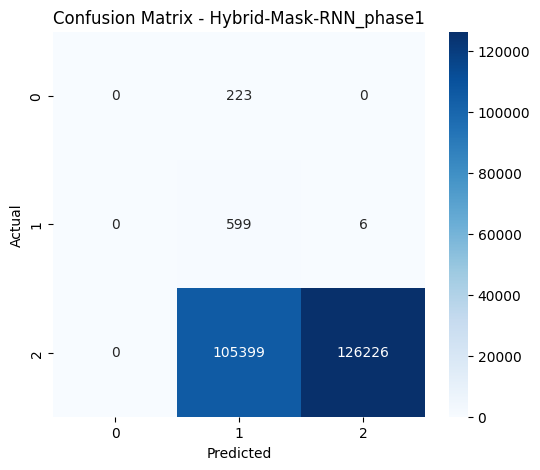

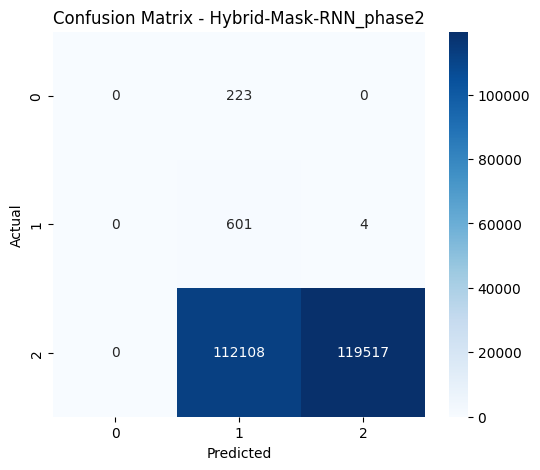

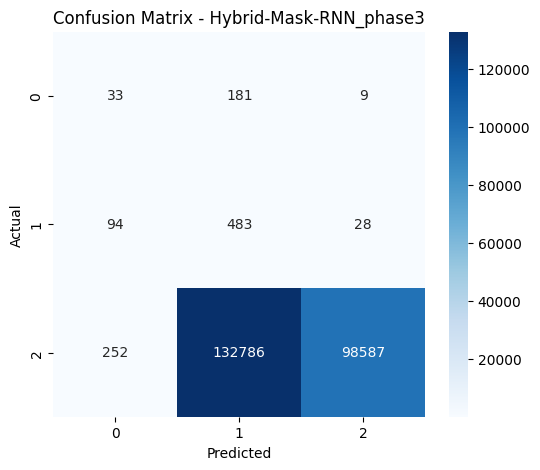

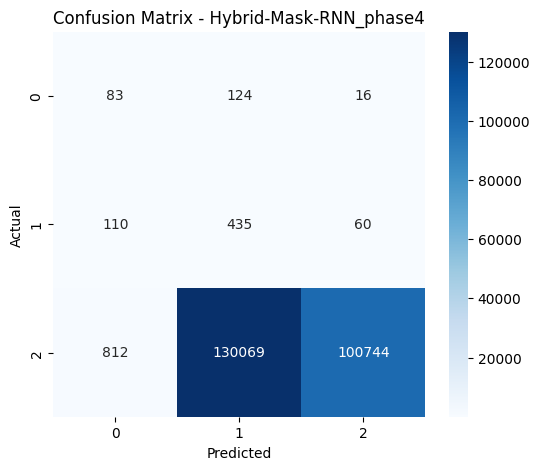

In [10]:
# ===== RNN =====
df_rnn = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_raw.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="Hybrid-Mask-RNN",
    rnn_type="rnn"
)
df_rnn


#####
Version: Hybrid-Mask-LSTM
#####
Loading train: /kaggle/input/lo-dataset/Raw/Raw/train_raw.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0248
Epoch 2: loss = 0.0150
Epoch 3: loss = 0.0148
Epoch 4: loss = 0.0147
Epoch 5: loss = 0.0146
Epoch 6: loss = 0.0145
Epoch 7: loss = 0.0144
Epoch 8: loss = 0.0144
Epoch 9: loss = 0.0143
Epoch 10: loss = 0.0142
Epoch 11: loss = 0.0142
Epoch 12: loss = 0.0141
Epoch 13: loss = 0.0141
Epoch 14: loss = 0.0140
Epoch 15: loss = 0.0140
Epoch 16: loss = 0.0140
Epoch 17: loss = 0.0139
Epoch 18: loss = 0.0139
Epoch 19: loss = 0.0138
Epoch 20: loss = 0.0138
Epoch 21: loss = 0.0138
Epoch 22: loss = 0.0138
Epoch 23: loss = 0.0137
Epoch 24: loss = 0.0137
Epoch 25: loss = 0.0137
Epoch 26: loss = 0.0136
Epoch 27: loss = 0.0136
Epoch 28: loss = 0.0136
Epoch 29: loss = 0.0135
E

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,Hybrid-Mask-LSTM,1,1503.049426,0.012032,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,Hybrid-Mask-LSTM,2,1503.049426,0.010857,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
2,Hybrid-Mask-LSTM,3,1503.049426,0.009456,0.996386,0.334415,0.373815,0.993222,0.334415,0.996386,0.334877,0.994651,0.000000,0.016973,0.004623,0.000000,0.000000,0.000000,0.00000,0.125000,0.003306,0.006441,0.057494,0.996446,0.999940,0.998190,0.049146
3,Hybrid-Mask-LSTM,4,1503.049426,0.008955,0.995457,0.363946,0.656953,0.994332,0.363946,0.995457,0.378146,0.994501,0.233176,0.110795,0.101170,0.857143,0.026906,0.052174,0.16403,0.116959,0.066116,0.084477,0.256962,0.996756,0.998817,0.997785,0.300787


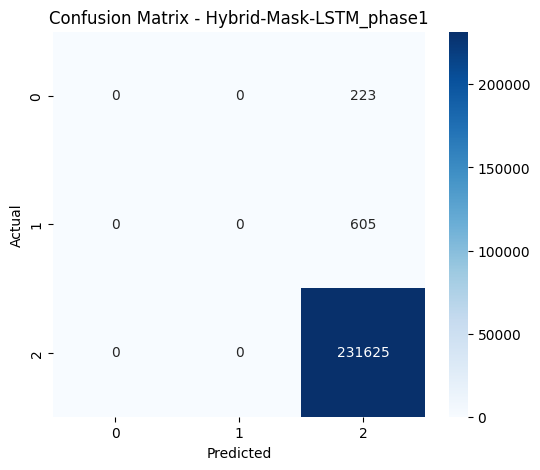

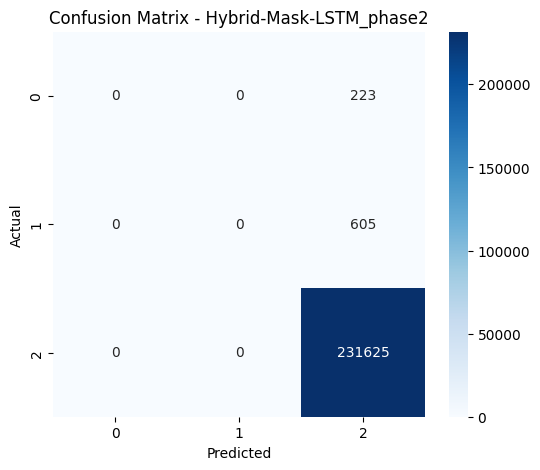

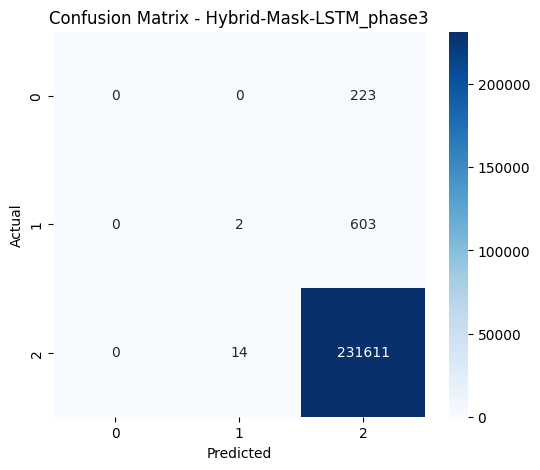

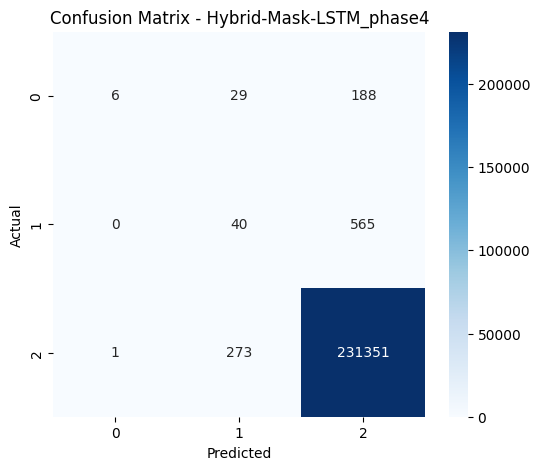

In [11]:
# ===== LSTM =====
df_lstm = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_raw.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="Hybrid-Mask-LSTM",
    rnn_type="lstm"
)
df_lstm


#####
Version: Hybrid-Mask-GRU
#####
Loading train: /kaggle/input/lo-dataset/Raw/Raw/train_raw.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0236
Epoch 2: loss = 0.0151
Epoch 3: loss = 0.0149
Epoch 4: loss = 0.0148
Epoch 5: loss = 0.0146
Epoch 6: loss = 0.0146
Epoch 7: loss = 0.0145
Epoch 8: loss = 0.0145
Epoch 9: loss = 0.0144
Epoch 10: loss = 0.0144
Epoch 11: loss = 0.0143
Epoch 12: loss = 0.0143
Epoch 13: loss = 0.0142
Epoch 14: loss = 0.0142
Epoch 15: loss = 0.0141
Epoch 16: loss = 0.0141
Epoch 17: loss = 0.0140
Epoch 18: loss = 0.0140
Epoch 19: loss = 0.0140
Epoch 20: loss = 0.0139
Epoch 21: loss = 0.0139
Epoch 22: loss = 0.0139
Epoch 23: loss = 0.0139
Epoch 24: loss = 0.0138
Epoch 25: loss = 0.0138
Epoch 26: loss = 0.0138
Epoch 27: loss = 0.0138
Epoch 28: loss = 0.0137
Epoch 29: loss = 0.0137
Ep

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,Hybrid-Mask-GRU,1,1468.151891,0.010459,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,Hybrid-Mask-GRU,2,1468.151891,0.009724,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
2,Hybrid-Mask-GRU,3,1468.151891,0.009399,0.996395,0.333868,0.359925,0.993110,0.333868,0.996395,0.333812,0.994647,0.0000,0.009675,0.002293,0.000000,0.000000,0.000000,0.000000,0.083333,0.001653,0.003241,0.040655,0.996442,0.999953,0.998194,0.034752
3,Hybrid-Mask-GRU,4,1468.151891,0.008892,0.993134,0.342908,0.449142,0.993319,0.342908,0.993134,0.344671,0.993078,0.1284,0.017890,0.017886,0.333333,0.008969,0.017467,0.094702,0.017588,0.023140,0.019986,0.151863,0.996503,0.996615,0.996559,0.147192


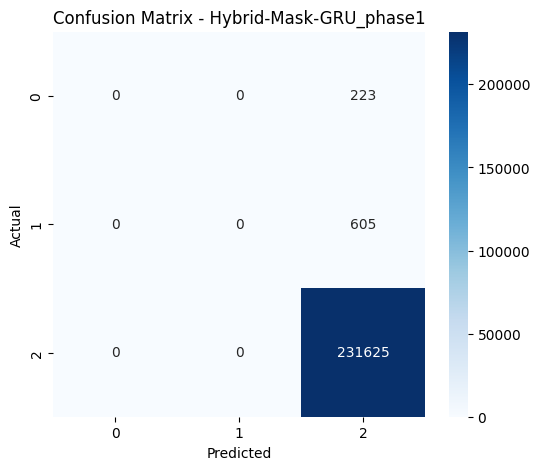

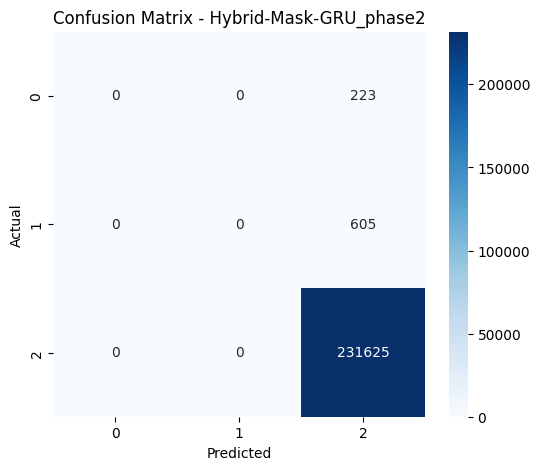

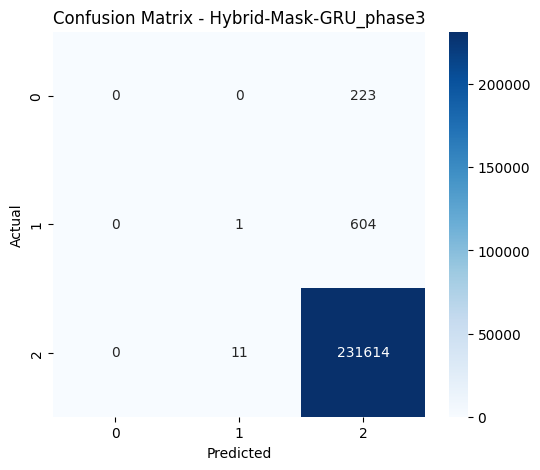

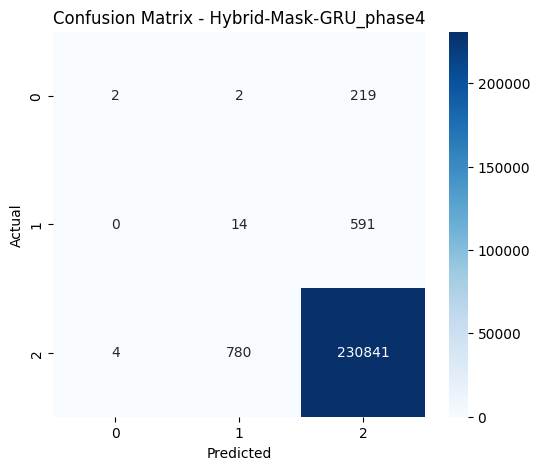

In [12]:
# ===== GRU =====
df_gru = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_raw.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="Hybrid-Mask-GRU",
    rnn_type="gru"
)
df_gru


#####
Version: Hybrid-Mask-BiLSTM
#####
Loading train: /kaggle/input/lo-dataset/Raw/Raw/train_raw.csv
Combined train + val: 2092071 samples
Phase 1: 39 features
Phase 2: 39 features
Phase 3: 39 features
Phase 4: 39 features
Time-series shape: (2092071, 4, 39)
Static feature shape: (2092071, 23)
Classes: [0 1 2]
Epoch 1: loss = 0.0224
Epoch 2: loss = 0.0151
Epoch 3: loss = 0.0148
Epoch 4: loss = 0.0147
Epoch 5: loss = 0.0146
Epoch 6: loss = 0.0145
Epoch 7: loss = 0.0144
Epoch 8: loss = 0.0143
Epoch 9: loss = 0.0143
Epoch 10: loss = 0.0142
Epoch 11: loss = 0.0141
Epoch 12: loss = 0.0141
Epoch 13: loss = 0.0140
Epoch 14: loss = 0.0140
Epoch 15: loss = 0.0140
Epoch 16: loss = 0.0139
Epoch 17: loss = 0.0139
Epoch 18: loss = 0.0138
Epoch 19: loss = 0.0138
Epoch 20: loss = 0.0138
Epoch 21: loss = 0.0137
Epoch 22: loss = 0.0137
Epoch 23: loss = 0.0136
Epoch 24: loss = 0.0136
Epoch 25: loss = 0.0136
Epoch 26: loss = 0.0135
Epoch 27: loss = 0.0135
Epoch 28: loss = 0.0135
Epoch 29: loss = 0.0134

,Version,Phase,TimeBuildModel,TimePredict,Accuracy,BalancedAcc,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted,F1-Score Macro,F1-Score Weighted,GMean,MCC,Kappa,Precision_Excellent,Recall_Excellent,F1-Score_Excellent,G-Mean_Excellent,Precision_Good,Recall_Good,F1-Score_Good,G-Mean_Good,Precision_Average,Recall_Average,F1-Score_Average,G-Mean_Average
0,Hybrid-Mask-BiLSTM,1,1641.756436,0.015719,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
1,Hybrid-Mask-BiLSTM,2,1641.756436,0.013100,0.996438,0.333333,0.332146,0.992889,0.333333,0.996438,0.332739,0.994660,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.996438,1.000000,0.998216,0.000000
2,Hybrid-Mask-BiLSTM,3,1641.756436,0.011058,0.996459,0.336088,0.665486,0.995513,0.336088,0.996459,0.338207,0.994714,0.0,0.077581,0.011968,0.0,0.0,0.0,0.0,1.000000,0.008264,0.016393,0.090909,0.996459,1.000000,0.998227,0.077709
3,Hybrid-Mask-BiLSTM,4,1641.756436,0.010369,0.995905,0.370523,0.412937,0.993896,0.370523,0.995905,0.383831,0.994837,0.0,0.161275,0.140226,0.0,0.0,0.0,0.0,0.241993,0.112397,0.153499,0.335102,0.996817,0.999171,0.997993,0.327718


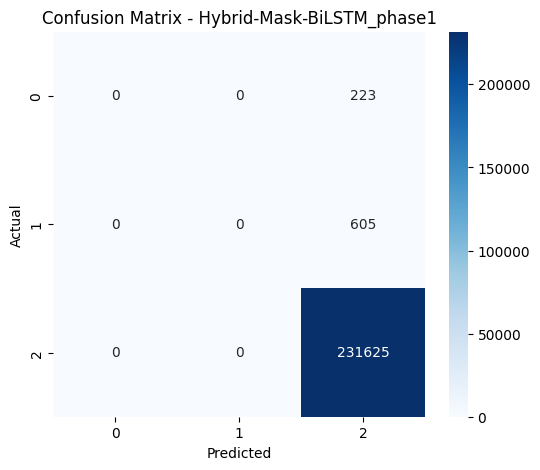

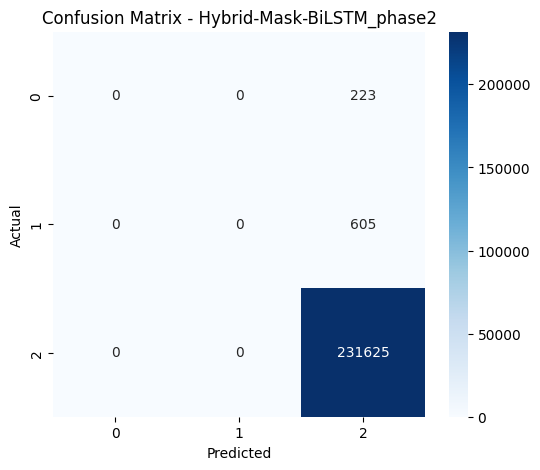

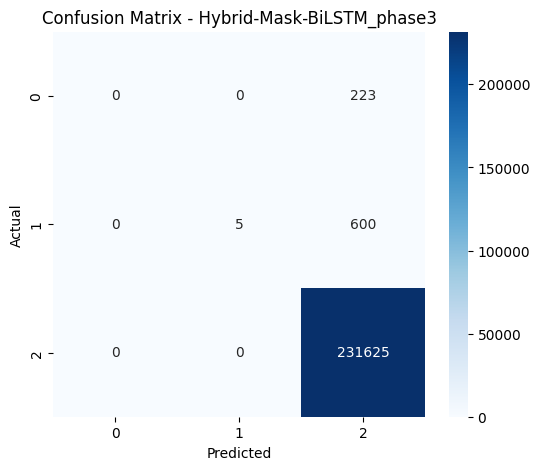

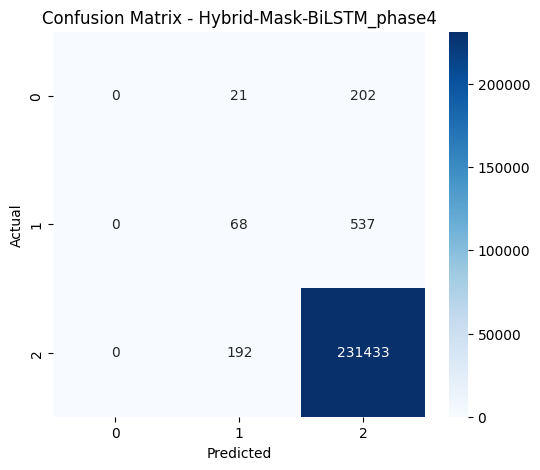

In [13]:
# ===== BiLSTM =====
df_bilstm = run_experiment_hybrid(
    base_path=base_path,
    train_file="train_raw.csv",
    val_file="val.csv",
    test_prefix="test",
    version_name="Hybrid-Mask-BiLSTM",
    rnn_type="bilstm"
)
df_bilstm

In [14]:
df_bilstm.to_csv("results.csv", index=False)